In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("data/train.csv",encoding="utf-8")
test_df = pd.read_csv("data/test.csv",encoding="utf-8")

In [3]:
train_df.shape

(891, 12)

In [4]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
test_df.shape

(418, 11)

In [7]:
train_df["train_col"] = 1
test_df["train_col"] = 0

In [8]:
merged_df = pd.concat([train_df,test_df],axis=0)

In [9]:
merged_df.shape

(1309, 13)

In [10]:
merged_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
train_col         0
dtype: int64

In [11]:
age_df = merged_df.copy()

In [12]:
age_df = age_df.drop(["Survived","Cabin"],axis=1)

In [13]:
age_df.dropna(subset=["Fare","Embarked"],inplace=True)

In [14]:
age_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            263
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
train_col        0
dtype: int64

In [15]:
get_name = age_df["Name"].apply(lambda x: x.split(",")[1])
get_title = get_name.apply(lambda x: x.split(".")[0])
age_df["Title"] = get_title

In [16]:
age_df["Title"].value_counts()

Title
Mr              756
Miss            259
Mrs             196
Master           61
Rev               8
Dr                8
Col               4
Ms                2
Major             2
Mlle              2
Don               1
Mme               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

In [17]:
title_map = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mrs": "Mrs",
    "Mme": "Mrs",
    "Master": "Master",
    "Rev": "Rare",
    "Dr": "Rare",
    "Col": "Rare",
    "Major": "Rare",
    "Don": "Rare",
    "Dona": "Rare",
    "Lady": "Rare",
    "Sir": "Rare",
    "Capt": "Rare",
    "the Countess": "Rare",
    "Jonkheer": "Rare",
}

age_df["Title"] = age_df["Title"].str.strip().map(title_map)

In [18]:
age_df.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,train_col,Title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Mr


In [19]:
age_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'train_col', 'Title'],
      dtype='str')

In [20]:
from sklearn.preprocessing import OrdinalEncoder

or_cols = ['Title','Embarked','Sex','Ticket']

scalers = {}
for col in or_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    age_df[col] = enc.fit_transform(age_df[[col]])

age_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,train_col,Title
0,1,3,"Braund, Mr. Owen Harris",1.0,22.0,1,0,718.0,7.2500,2.0,1,2.0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.0,38.0,1,0,814.0,71.2833,0.0,1,3.0
2,3,3,"Heikkinen, Miss. Laina",0.0,26.0,0,0,912.0,7.9250,2.0,1,1.0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.0,35.0,1,0,64.0,53.1000,2.0,1,3.0
4,5,3,"Allen, Mr. William Henry",1.0,35.0,0,0,647.0,8.0500,2.0,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",1.0,NaN,0,0,709.0,8.0500,2.0,0,2.0
414,1306,1,"Oliva y Ocana, Dona. Fermina",0.0,39.0,0,0,832.0,108.9000,0.0,0,4.0
415,1307,3,"Saether, Mr. Simon Sivertsen",1.0,38.5,0,0,870.0,7.2500,2.0,0,2.0
416,1308,3,"Ware, Mr. Frederick",1.0,NaN,0,0,578.0,8.0500,2.0,0,2.0


In [21]:
age_con = age_df["Age"].isna()

age_na = age_df[age_con]
age_not_na = age_df[~age_con]

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

iners = []
sil_scores = []

features = ["Pclass","Sex","SibSp","Parch","Ticket","Embarked","Title"]
data = age_df[features]

r = range(2,40)
for i in r:
    model = KMeans(n_clusters=i)
    model.fit(data)
    iner = model.inertia_
    sil_score = silhouette_score(data, model.predict(data))
    sil_scores.append(sil_score)
    iners.append(iner)
    print(f"n_clusters:{i}, sil_score:{sil_score}, inertia:{iner}")

n_clusters:2, sil_score:0.6488853669200084, inertia:22654459.710155495
n_clusters:3, sil_score:0.6066103087131817, inertia:9939029.467074938
n_clusters:4, sil_score:0.5864469748255469, inertia:5566725.133576351
n_clusters:5, sil_score:0.5831154774944717, inertia:3494931.793433569
n_clusters:6, sil_score:0.5592171166270921, inertia:2609684.6931088255
n_clusters:7, sil_score:0.5430549504437819, inertia:1891433.3785787113
n_clusters:8, sil_score:0.5450140217778433, inertia:1456716.4579681105
n_clusters:9, sil_score:0.5420954512475943, inertia:1264281.9796660377
n_clusters:10, sil_score:0.5198936795088284, inertia:976343.3335388538
n_clusters:11, sil_score:0.536478316970032, inertia:788510.8636273505
n_clusters:12, sil_score:0.5391869619642465, inertia:648536.3198997898
n_clusters:13, sil_score:0.5380662688496751, inertia:559160.2184671756
n_clusters:14, sil_score:0.537743762256973, inertia:469425.5527897269
n_clusters:15, sil_score:0.5427727550499828, inertia:395044.0643641056
n_clusters:

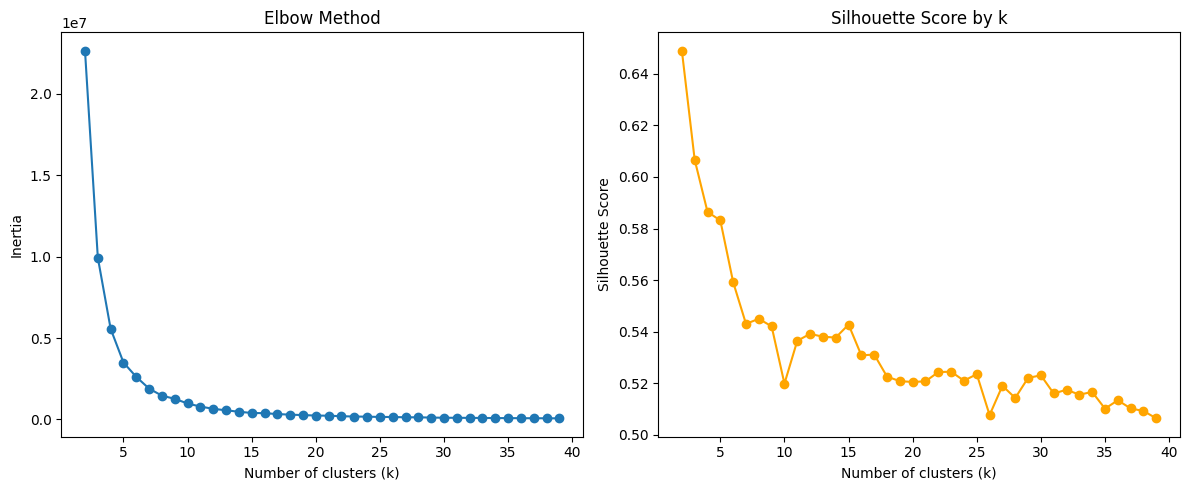

In [29]:
import matplotlib.pyplot as plt

k_range = r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_range, iners, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, sil_scores, marker="o", color="orange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

In [37]:
for x in range(3,7,1):
    k_best = KMeans(n_clusters=x)
    clusters = k_best.fit_predict(age_df[features])
    age_df["cluster"] = clusters

    age_stats = age_df.groupby("cluster")["Age"].agg(["mean", "std", "var", "count"])
    print(age_stats)

              mean        std         var  count
cluster                                         
0        25.822271  12.312289  151.592451    317
1        30.391653  14.630155  214.041424    363
2        32.719945  14.998515  224.955456    363
              mean        std         var  count
cluster                                         
0        35.324733  14.366088  206.384476    281
1        30.341419  14.161219  200.540136    310
2        26.294439  13.414795  179.956734    223
3        25.761659  13.280062  176.360046    229
              mean        std         var  count
cluster                                         
0        30.631765  14.556922  211.903968    272
1        26.431159  13.767160  189.534695    207
2        28.741986  13.850079  191.824686    146
3        25.451564  12.331416  152.063814    179
4        35.731883  14.379377  206.766493    239
              mean        std         var  count
cluster                                         
0        30.851518  

In [38]:
k_best = KMeans(n_clusters=5)
clusters = k_best.fit_predict(age_df[features])
age_df["cluster"] = clusters

In [39]:
cluster_means = age_df.groupby("cluster")["Age"].transform("mean")
age_df["Age"] = age_df["Age"].fillna(cluster_means)

In [40]:
cluster_means

0      27.869177
1      30.760290
2      30.760290
3      35.687426
4      27.869177
         ...    
413    27.869177
414    30.760290
415    30.760290
416    27.869177
417    26.865578
Name: Age, Length: 1306, dtype: float64

In [42]:
age_df["Age"].isna().sum()

np.int64(0)

In [43]:
age_df.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
train_col      0
Title          0
cluster        0
dtype: int64